# **DATA 543 Spring 2026: CA Energy Prices**

In [44]:
########################################################################
# Base Packages - Required Non-Base Packages to Run (torch, scikit-learn)
########################################################################

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import scipy.stats
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
###################################################################
# Import Data from the Github Repo and Clean + Format
###################################################################

base_path = 'Local Data/'
start_date = '2010-01-09'
end_date = '2025-12-31'

df_localtemps = pd.read_csv(base_path +'local_weather.csv') #daily temp observations, precipitation at Shasta Dam
df_localtemps = df_localtemps.drop(columns=['STATION', 'NAME', 'DAPR', 'MDPR', 'SNOW', 'SNWD'])
df_localtemps['DATE'] = pd.to_datetime(df_localtemps['DATE'], format='mixed')
df_localtemps.columns = ['Date', 'Precipitation', 'Max Temp (F)', 'Min Temp (F)', 'Observed Temp (F)']
df_localtemps = df_localtemps.set_index('Date').sort_index()

df_hdd_cdd = pd.read_csv(base_path + 'hdd_cdd.csv') #monthly hdd and cdd
df_hdd_cdd['Date'] = pd.to_datetime(df_hdd_cdd['Date'], format='%Y%m')
df_hdd_cdd = df_hdd_cdd.set_index('Date').sort_index()
df_hdd_cdd = df_hdd_cdd.resample('D').ffill() #fill out monthly data to days

df_ONI = pd.read_csv(base_path + 'Monthly Oceanic Nino Index (ONI) - Long.csv') #monthly
df_ONI['Date'] = pd.to_datetime(dict(year=df_ONI['Year'], month=df_ONI['MonthNum'], day=1)) #dataframe ends 12-01-2025 not 12-31 so need to manually add the extra days so that there are no NaN entries to the model
df_ONI = df_ONI.set_index('Date').sort_index()
df_ONI = df_ONI.drop(columns = ['Year', 'MonthTxt', 'MonthNum'])
last = df_ONI.index.max()
next_month = last + pd.offsets.MonthBegin(1)
df_ONI.loc[next_month] = df_ONI.loc[last]
df_ONI = df_ONI.resample('D').ffill()
df_ONI.columns = ['ONI']

df_pricedata = pd.read_csv(base_path + 'price_data.csv')
df_pricedata.columns = ['Date', 'PX_LAST', 'Lag [t-1]', 'Lag [t-7]', 'Rolling Average [7d]', 'Rolling Average [30d]', 'NatGas Lag [t-1]', 'NatGas Lag [t-7]', 'NatGas Rolling [7d]', 'NatGas Rolling [30d]', 'NatGas Rolling 2 [30d]'] #temporary we can name these whatever evenutally
df_pricedata['Date'] = pd.to_datetime(df_pricedata['Date'], format='%m/%d/%Y')
df_pricedata = df_pricedata.set_index('Date').sort_index()
df_pricedata = df_pricedata.drop(columns = ['NatGas Rolling 2 [30d]'])

df_1day_load = pd.read_csv(base_path + 'caiso_load_forecast_daily_2010_2026.csv')
df_1day_load['date'] = pd.to_datetime(df_1day_load['date'], format='mixed')
df_1day_load.columns = ['Date', 'Mean Hourly Forecast [MW]', 'Max Hourly Forecast [MW]', 'Min Hourly Forecast [MW]']
df_1day_load = df_1day_load.set_index('Date').sort_index()
#print(df_1day_load.shape[0])

df_7day_load = pd.read_csv(base_path + 'caiso_tac_7day_load_forecast_daily_2010_2026.csv')
df_7day_load['date'] = pd.to_datetime(df_7day_load['date'], format='mixed')
df_7day_load['date'] = df_7day_load['date'] - timedelta(weeks = 1)
df_7day_load = df_7day_load.drop(columns=['pge_7day_load_forecast_hours', 'first_publish_time', 'last_publish_time'])
df_7day_load.columns = ['Date', 'Week-Ahead Mean Daily Forecast [MW]', 'Week-Ahead Max Daily Forecast [MW]', 'Week-Ahead Min Daily Forecast [MW]']
df_7day_load = df_7day_load.set_index('Date').sort_index()
#print(df_7day_load.shape[0])

dfs = [df_hdd_cdd, df_ONI, df_localtemps, df_pricedata, df_1day_load, df_7day_load] #add new dataframes here

####################################################################################
# double check no duplicates, aligned indexes, etc. to prepare for splice and join
####################################################################################

cleaned = []
for df in dfs:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    cleaned.append(df)
dfs = cleaned
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata, df_1day_load, df_7day_load = dfs #add back in any new dataframes

    
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata, df_1day_load, df_7day_load = dfs #add back in any new dataframes

####################################################################################
# Final Concatenation, Formatting to feed into ML models
####################################################################################

monthly_df_list = [df_hdd_cdd, df_ONI]
daily_df_list = [df_pricedata, df_localtemps]
load_df_list = [df_1day_load, df_7day_load]

df_monthly = pd.concat(monthly_df_list, axis=1, join='outer') #join into seperate sets for later
df_daily = pd.concat(daily_df_list, axis=1, join='outer')
df_load = pd.concat(load_df_list, axis = 1, join = 'outer')

n_vars_monthly = df_monthly.shape[1] #variable so we don't have to mess with stuff in the model as we add stuff
n_vars_daily = df_daily.shape[1]
n_vars_load = df_load.shape[1]

df_load_daily_combined = pd.concat([df_daily, df_load], axis = 1, join = 'outer')
combined_df = pd.concat([df_monthly, df_daily], axis = 1, join = 'outer') #one total dataframe

5836


In [46]:
df_daily

,PX_LAST,Lag [t-1],Lag [t-7],Rolling Average [7d],Rolling Average [30d],NatGas Lag [t-1],NatGas Lag [t-7],NatGas Rolling [7d],NatGas Rolling [30d],Precipitation,Max Temp (F),Min Temp (F),Observed Temp (F)
Date,,,,,,,,,,,,,
2010-01-09,48.46,55.16,45.14,51.217143,50.457500,5.92,5.92,6.248,6.248000,0.16,47.0,41.0,45.897837
2010-01-10,48.37,48.46,50.90,50.855714,50.225556,5.92,5.92,6.248,6.248000,0.05,54.0,45.0,46.086377
2010-01-11,53.43,48.37,50.21,51.315714,50.546000,5.85,5.95,6.182,6.193333,0.00,56.0,42.0,43.103282
2010-01-12,52.36,53.43,51.60,51.424286,50.710909,5.90,6.11,6.100,6.144286,0.95,50.0,43.0,45.168006
2010-01-13,49.04,52.36,49.69,51.331429,50.571667,6.07,6.03,6.042,6.113750,2.57,52.0,45.0,47.043405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,17.35,30.33,0.00,21.834286,38.462000,3.00,2.24,2.410,3.486923,1.90,56.0,35.0,35.000000
2025-12-28,17.35,17.35,0.00,24.312857,37.372000,3.00,2.24,2.410,3.486923,0.00,50.0,35.0,44.909204
2025-12-29,33.23,17.35,0.00,29.060000,36.798000,3.00,2.24,2.300,3.486923,0.00,56.0,43.0,46.998529


In [47]:
df_monthly

,HDD (F),CDD (F),ONI
Date,,,
2010-01-09,492,0,1.3
2010-01-10,492,0,1.3
2010-01-11,492,0,1.3
2010-01-12,492,0,1.3
2010-01-13,492,0,1.3
...,...,...,...
2025-12-27,358,5,-0.5
2025-12-28,358,5,-0.5
2025-12-29,358,5,-0.5


In [56]:
df_load

,Mean Hourly Forecast [MW],Max Hourly Forecast [MW],Min Hourly Forecast [MW],Week-Ahead Mean Daily Forecast [MW],Week-Ahead Max Daily Forecast [MW],Week-Ahead Min Daily Forecast [MW]
Date,,,,,,
2010-01-09,23281.458333,27557.00,19591.00,23292.625000,27524.00,19699.50
2010-01-10,22432.000000,27414.00,18946.00,22416.979167,27328.50,19381.00
2010-01-11,25120.354167,30091.50,18970.00,24925.229167,29954.50,19441.50
2010-01-12,25317.250000,30006.50,19608.00,25856.583333,30724.00,19925.50
2010-01-13,25259.104167,30054.50,19597.50,26131.291667,30891.00,20365.50
...,...,...,...,...,...,...
2025-12-27,20500.366250,24190.48,16654.74,21503.538333,25034.40,18844.52
2025-12-28,20407.457917,25055.89,15305.02,21499.080417,25381.66,19187.00
2025-12-29,22993.606667,27599.08,19685.22,23935.740000,27748.36,19463.93


X_daily any NaN: False
X_month any NaN: False
y any NaN: False
X_daily any Inf: False
X_month any Inf: False
y any Inf: False
X_daily: (5814, 12, 15)
X_month: (5814, 3)
y: (5814, 7)
Daily features used: ['Lag [t-1]', 'Lag [t-7]', 'Rolling Average [7d]', 'Rolling Average [30d]', 'NatGas Lag [t-1]', 'NatGas Lag [t-7]', 'NatGas Rolling [7d]', 'NatGas Rolling [30d]', 'Precipitation', 'Max Temp (F)', 'Min Temp (F)', 'Observed Temp (F)']
Epoch 01 | Train Loss: 410.4208 | Val Loss: 1180.3156
Epoch 02 | Train Loss: 262.6321 | Val Loss: 1174.8106
Epoch 03 | Train Loss: 254.2883 | Val Loss: 1121.3938
Epoch 04 | Train Loss: 244.5208 | Val Loss: 1173.2161
Epoch 05 | Train Loss: 239.6002 | Val Loss: 1293.4912
Epoch 06 | Train Loss: 239.5774 | Val Loss: 1006.9836
Epoch 07 | Train Loss: 228.9517 | Val Loss: 994.3898
Epoch 08 | Train Loss: 235.3668 | Val Loss: 916.4393
Epoch 09 | Train Loss: 227.8260 | Val Loss: 981.6175
Epoch 10 | Train Loss: 223.7658 | Val Loss: 985.1351
Epoch 11 | Train Loss: 231.9

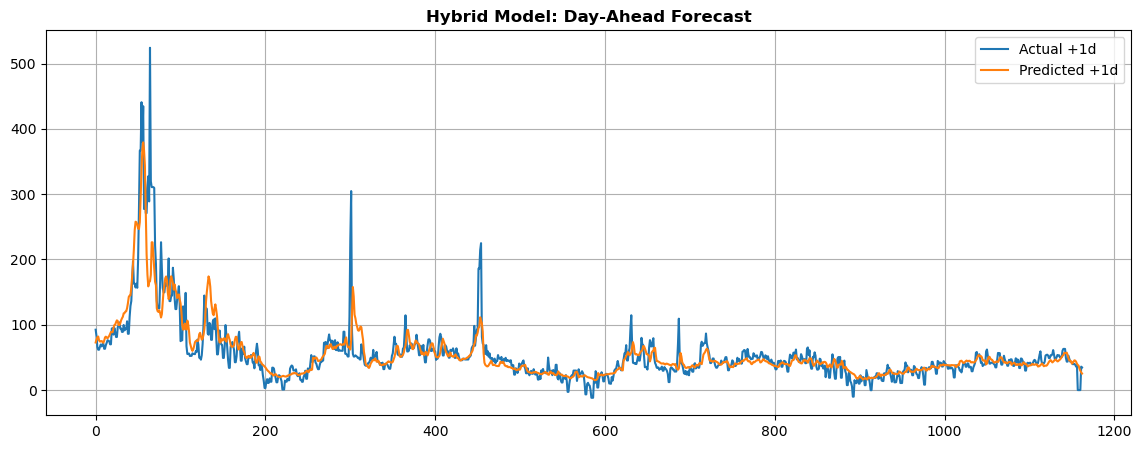

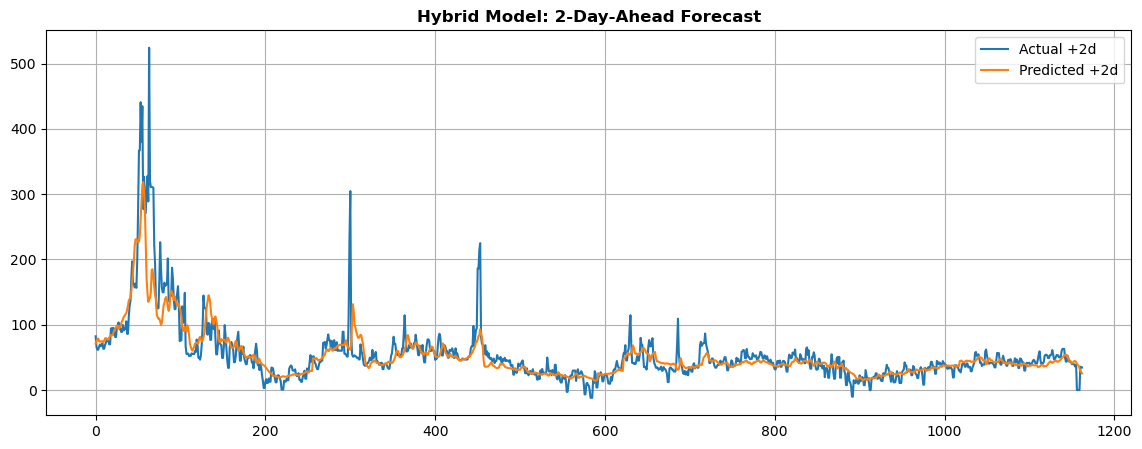

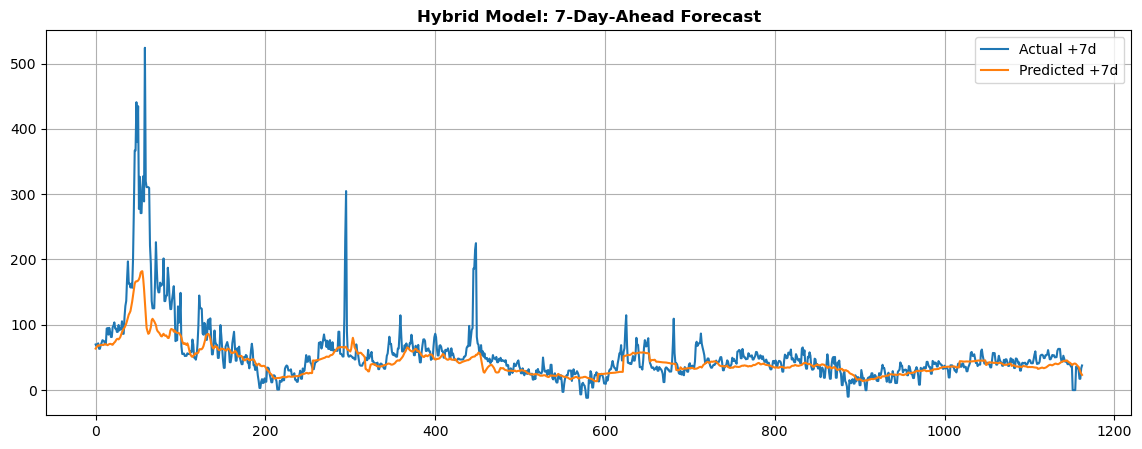

In [ ]:
############################################################################

#print("df_daily NaNs:\n", df_daily.isna().sum())  ####DATA CLEANING CHECKS
#print("df_monthly NaNs:\n", df_monthly.isna().sum())
#print("df_daily index freq:", df_daily.index.inferred_freq)
#print("df_monthly index freq:", df_monthly.index.inferred_freq)

############################################################################
# Create sliding windows with daily + monthly features
#  X_daily: (samples, n_daily_features_excluding_target, window)
#  X_month: (samples, n_vars_monthly)
#  y:       (samples, horizon) !!! PX_LAST only here
############################################################################

def create_hybrid_windows(daily_df, monthly_daily_df, target_col="PX_LAST", window=15, horizon=7):
    X_daily, X_month, y = [], [], []

    # Explicitly exclude target from daily input features
    daily_feature_df = daily_df.drop(columns=[target_col])
    target_vals = daily_df[target_col].values              # keep target separate
    daily_feature_vals = daily_feature_df.values
    monthly_vals = monthly_daily_df.values
    n = len(daily_df)

    for i in range(n - window - horizon):
        X_daily.append(daily_feature_vals[i:i+window].T) # Daily predictors
        X_month.append(monthly_vals[i+window-1]) # Monthly features at last day of window
        y.append(target_vals[i+window:i+window+horizon]) # Future target sequence

    X_daily = np.array(X_daily)
    X_month = np.array(X_month)
    y = np.array(y)

    #print("X_daily any NaN:", np.isnan(X_daily).any())
    #print("X_month any NaN:", np.isnan(X_month).any())
    #print("y any NaN:", np.isnan(y).any())

    #print("X_daily any Inf:", np.isinf(X_daily).any())
    #print("X_month any Inf:", np.isinf(X_month).any())
    #print("y any Inf:", np.isinf(y).any())

    return X_daily, X_month, y, daily_feature_df.columns

window = 15
horizon = 7

X_daily, X_month, y, daily_feature_cols = create_hybrid_windows(df_daily,df_monthly,target_col="PX_LAST",window=window,horizon=horizon)

#print("X_daily:", X_daily.shape)
#print("X_month:", X_month.shape)
#print("y:", y.shape)

print("Daily features used:", list(daily_feature_cols))            

######################################################################
# Dataset + DataLoader
######################################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]

split = int(0.8 * len(X_daily))
train_ds = HybridClimateDataset(X_daily[:split], X_month[:split], y[:split])
val_ds   = HybridClimateDataset(X_daily[split:], X_month[split:], y[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

##########################################################################
# Month/Day Hybid model
##########################################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        # Daily CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2), #padding prevents data loss on the edges of the set
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Monthly MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion + output
        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        daily_latent = self.cnn(x_daily).squeeze(-1)  # (batch, 64)
        month_latent = self.mlp(x_month)              # (batch, 32)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)

model = HybridCNN(
    in_channels_daily=X_daily.shape[1],
    monthly_features=n_vars_monthly,
    horizon=horizon
)

################################################################
# Training Loop
################################################################

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb_daily, xb_month)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = model(xb_daily, xb_month)
            val_loss += criterion(pred, yb).item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

###############################################################
# Prediction Set
###############################################################

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        preds.append(model(xb_daily, xb_month).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

###############################################################
# Results/Plotting
###############################################################

# Day-ahead (horizon 1)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,0], label="Actual +1d")
plt.plot(preds[:,0], label="Predicted +1d")
plt.title("Hybrid Model: Day-Ahead Forecast",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

# 2-day-ahead (horizon 2)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,1], label="Actual +2d")
plt.plot(preds[:,1], label="Predicted +2d")
plt.title("Hybrid Model: 2-Day-Ahead Forecast",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

# 7-day-ahead (horizon 7)
plt.figure(figsize=(14,5))
plt.plot(actuals[:,6], label="Actual +7d")
plt.plot(preds[:,6], label="Predicted +7d")
plt.title("Hybrid Model: 7-Day-Ahead Forecast",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

X_daily any NaN: False
X_month any NaN: False
y any NaN: False
X_daily any Inf: False
X_month any Inf: False
y any Inf: False
X_daily: (5814, 12, 15)
X_month: (5814, 3)
y: (5814, 7)
Daily features used: ['Lag [t-1]', 'Lag [t-7]', 'Rolling Average [7d]', 'Rolling Average [30d]', 'NatGas Lag [t-1]', 'NatGas Lag [t-7]', 'NatGas Rolling [7d]', 'NatGas Rolling [30d]', 'Precipitation', 'Max Temp (F)', 'Min Temp (F)', 'Observed Temp (F)']
Epoch 01 | Train Loss: 6.3430 | Val Loss: 7.6198
Epoch 02 | Train Loss: 2.9073 | Val Loss: 7.2612
Epoch 03 | Train Loss: 2.8518 | Val Loss: 6.4545
Epoch 04 | Train Loss: 2.7960 | Val Loss: 6.2790
Epoch 05 | Train Loss: 2.7769 | Val Loss: 5.8605
Epoch 06 | Train Loss: 2.7496 | Val Loss: 5.5283
Epoch 07 | Train Loss: 2.7146 | Val Loss: 5.5445
Epoch 08 | Train Loss: 2.6581 | Val Loss: 5.3906
Epoch 09 | Train Loss: 2.6661 | Val Loss: 5.7261
Epoch 10 | Train Loss: 2.6462 | Val Loss: 5.0438
Epoch 11 | Train Loss: 2.6020 | Val Loss: 5.6004
Epoch 12 | Train Loss: 2.

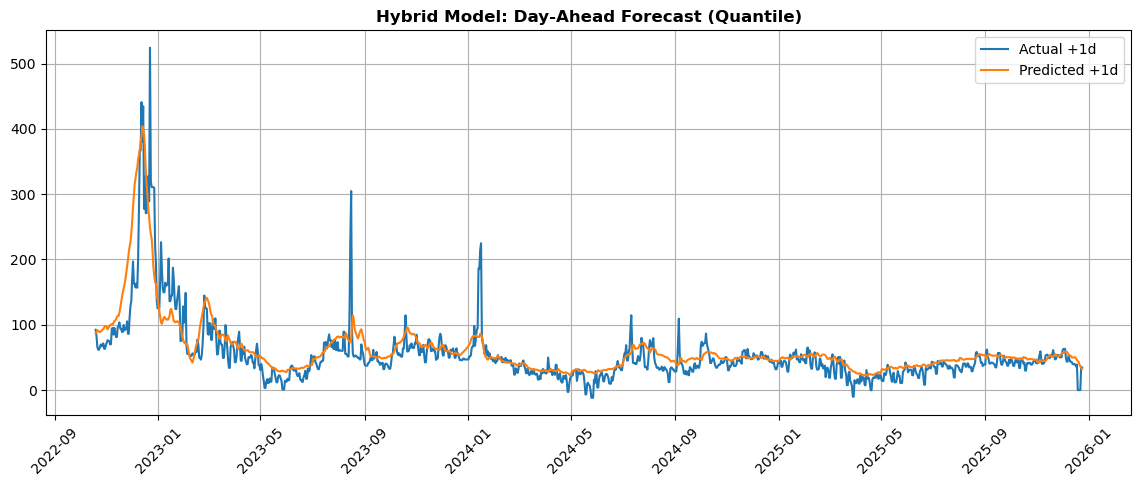

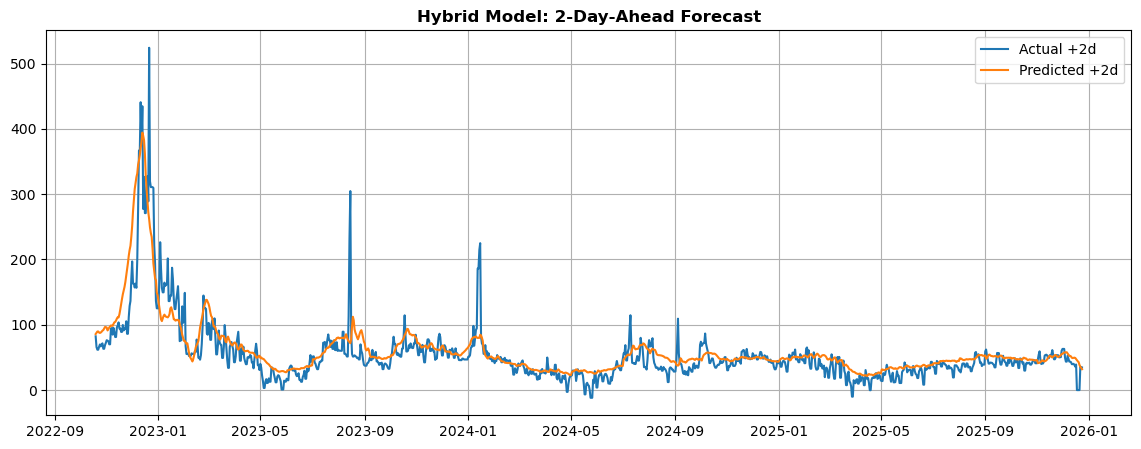

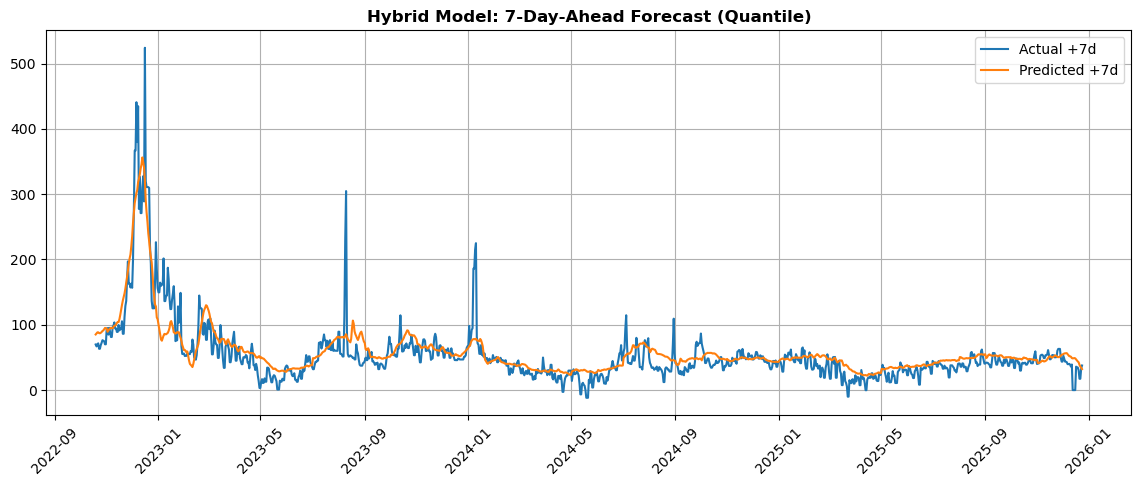

In [ ]:
############################################################################
# Try Same Process with Quantiles instead of RMSE
############################################################################

def create_hybrid_windows(daily_df, monthly_daily_df, target_col="PX_LAST", window=15, horizon=7):
    X_daily, X_month, y = [], [], []

    # Explicitly exclude target from daily input features
    daily_feature_df = daily_df.drop(columns=[target_col])
    target_vals = daily_df[target_col].values              # keep target separate
    daily_feature_vals = daily_feature_df.values
    monthly_vals = monthly_daily_df.values
    n = len(daily_df)

    for i in range(n - window - horizon):
        
        X_daily.append(daily_feature_vals[i:i+window].T) # Daily predictors 
        X_month.append(monthly_vals[i+window-1]) # Monthly features at last day of window
        y.append(target_vals[i+window:i+window+horizon]) # Future target sequence 

    X_daily = np.array(X_daily)
    X_month = np.array(X_month)
    y = np.array(y)

    #print("X_daily any NaN:", np.isnan(X_daily).any())
    #print("X_month any NaN:", np.isnan(X_month).any())
    #print("y any NaN:", np.isnan(y).any())

    #print("X_daily any Inf:", np.isinf(X_daily).any())
    #print("X_month any Inf:", np.isinf(X_month).any())
    #print("y any Inf:", np.isinf(y).any())

    return X_daily, X_month, y, daily_feature_df.columns

window = 15
horizon = 7

X_daily, X_month, y, daily_feature_cols = create_hybrid_windows(df_daily,df_monthly,target_col="PX_LAST",window=window,horizon=horizon)

#print("X_daily:", X_daily.shape)
#print("X_month:", X_month.shape)
#print("y:", y.shape)

print("Daily features used:", list(daily_feature_cols))         
n_vars_daily   = X_daily.shape[1]
n_vars_monthly = X_month.shape[1]

######################################################################
# DataSet Class
######################################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y       = torch.tensor(y,       dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]

split = int(0.8 * len(X_daily))
train_ds = HybridClimateDataset(X_daily[:split], X_month[:split], y[:split])
val_ds   = HybridClimateDataset(X_daily[split:], X_month[split:], y[split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

#######################################################################
# Hybrid model
#######################################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        # Daily CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Monthly MLP branch
        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion + output
        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        # x_daily: (batch, vars, window)
        daily_latent = self.cnn(x_daily).squeeze(-1)  # (batch, 64)
        month_latent = self.mlp(x_month)              # (batch, 32)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)

model = HybridCNN(
    in_channels_daily=n_vars_daily,
    monthly_features=n_vars_monthly,
    horizon=horizon
)

###################################################################
# Quantiles
###################################################################
def quantile_loss(q, y, f):
    e = y - f
    return torch.max(q * e, (q - 1) * e).mean()

q = 0.87  # Goal is to improve matching with peaks, volatility
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 25
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb_daily, xb_month)
        loss = quantile_loss(q, yb, pred)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = model(xb_daily, xb_month)
            val_loss += quantile_loss(q, yb, pred).item()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

###################################################################
# Predictions on Validation Set
###################################################################

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        out = model(xb_daily, xb_month)
        preds.append(out.detach().numpy())
        actuals.append(yb.detach().numpy())

preds   = np.vstack(preds)
actuals = np.vstack(actuals)

#####################################################################
# Results/Plotting
#####################################################################

val_dates = df_daily.index[window + split : window + split + len(actuals)] #fix x-axis dates

# 1-day ahead
plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,0], label="Actual +1d")
plt.plot(val_dates, preds[:,0],   label=f"Predicted +1d")
plt.title("Hybrid Model: Day-Ahead Forecast (Quantile)",fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 2-day ahead
plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,1], label="Actual +2d")
plt.plot(val_dates, preds[:,1], label="Predicted +2d")
plt.title("Hybrid Model: 2-Day-Ahead Forecast", fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.show()

#7-day ahead
plt.figure(figsize=(14,5))
plt.plot(val_dates, actuals[:,6], label="Actual +7d")
plt.plot(val_dates, preds[:,6],   label=f"Predicted +7d")
plt.title("Hybrid Model: 7-Day-Ahead Forecast (Quantile)", fontweight = 'semibold')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5836 entries, 2010-01-09 to 2025-12-31
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PX_LAST                5836 non-null   float64
 1   Lag [t-1]              5836 non-null   float64
 2   Lag [t-7]              5836 non-null   float64
 3   Rolling Average [7d]   5836 non-null   float64
 4   Rolling Average [30d]  5836 non-null   float64
 5   NatGas Lag [t-1]       5836 non-null   float64
 6   NatGas Lag [t-7]       5836 non-null   float64
 7   NatGas Rolling [7d]    5836 non-null   float64
 8   NatGas Rolling [30d]   5836 non-null   float64
 9   Precipitation          5836 non-null   float64
 10  Max Temp (F)           5836 non-null   float64
 11  Min Temp (F)           5836 non-null   float64
 12  Observed Temp (F)      5836 non-null   float64
dtypes: float64(13)
memory usage: 638.3 KB

=== Horizon: 1-day ahead ===
OOB Score: 0.636498171

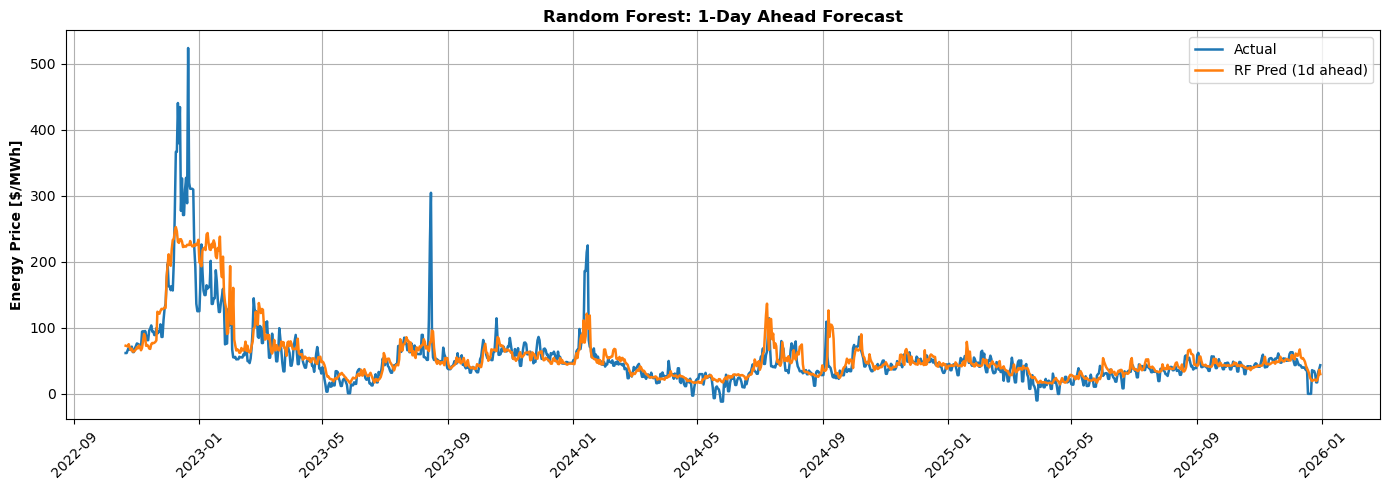


=== Horizon: 2-day ahead ===
OOB Score: 0.6970620752031076
MSE: 918.2207627169641
R-squared: 0.6295885489407498


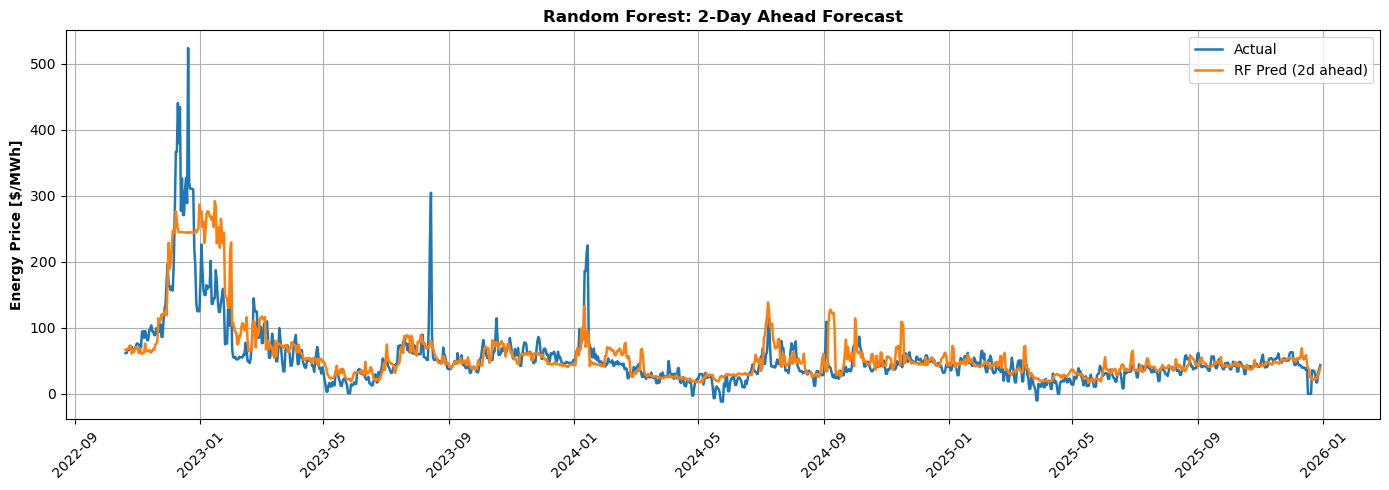


=== Horizon: 7-day ahead ===
OOB Score: 0.7158505902831545
MSE: 1262.238274766158
R-squared: 0.49123591863266347


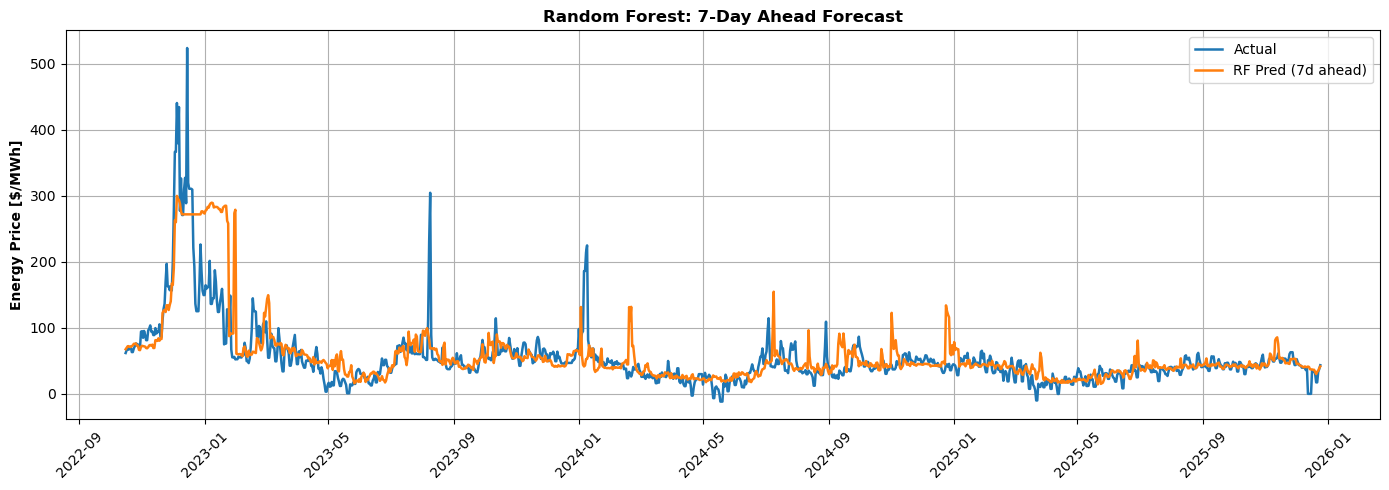


=== Forecast Metrics by Horizon ===


,Horizon (days),OOB Score,MAE,MSE,RMSE,R-squared
0,1,0.6365,14.063,713.343,26.708,0.7122
1,2,0.6971,16.834,918.221,30.302,0.6296
2,7,0.7159,18.393,1262.238,35.528,0.4912


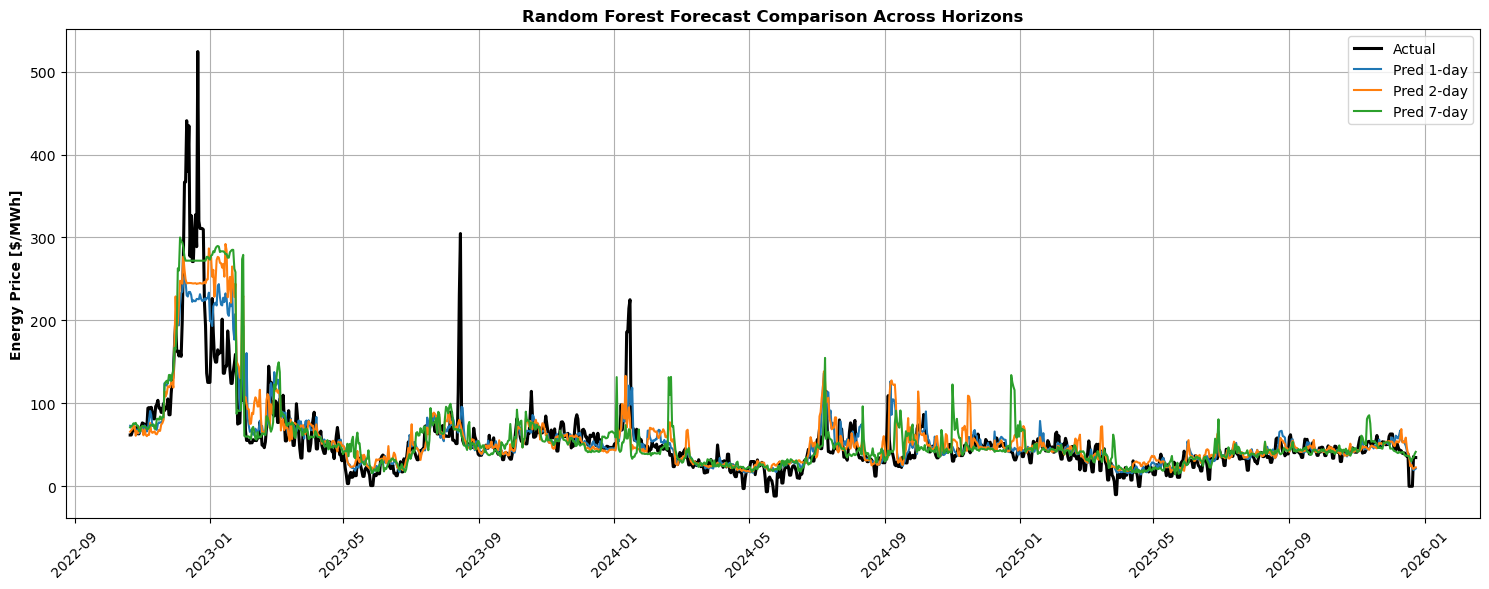

In [50]:
##########################################################################
# Random Forest Model for Comparison to CNN
##########################################################################

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#########################################################################
# Assign Features and Target
#########################################################################
df_rf = df_daily.copy()
df_rf.info()

feature_cols = df_rf.columns[1:n_vars_daily]  # lag/rolling/weather features
target_col = "PX_LAST"

#########################################################################
# Main Model Function
#########################################################################

def rf_horizon(df, feature_cols, target_col, horizon_days, test_size=0.2):
    """
    Direct forecast for a fixed horizon:
    y_t = target at t + horizon_days
    """
    data = df.copy()
    data[f"target_t_plus_{horizon_days}"] = data[target_col].shift(-horizon_days)

    # drop rows with NaN target created by shifting
    data = data.dropna(subset=[f"target_t_plus_{horizon_days}"])

    X = data[feature_cols]
    y = data[f"target_t_plus_{horizon_days}"]
    split_idx = int((1 - test_size) * len(data))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:] #chronological split
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = RandomForestRegressor(n_estimators=300,random_state=42,oob_score=True,n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== Horizon: {horizon_days}-day ahead ===")
    print("OOB Score:", model.oob_score_)
    print("MSE:", mse)
    print("R-squared:", r2)

    # Plot only test window (cleaner than plotting full-sample predictions)
    plt.figure(figsize=(14, 5))
    plt.plot(y_test.index, y_test.values, label="Actual", linewidth=1.8)
    plt.plot(y_test.index, y_pred, label=f"RF Pred ({horizon_days}d ahead)", linewidth=1.8)
    plt.title(f"Random Forest: {horizon_days}-Day Ahead Forecast", fontweight="semibold")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model, pd.Series(y_pred, index=y_test.index, name=f"pred_t_plus_{horizon_days}")

###############################################################################################
#Set up Prediction Intervals and Run Model
###############################################################################################

models = {}
preds = {}

for h in [1, 2, 7]:
    models[h], preds[h] = rf_horizon(
        df=df_rf,
        feature_cols=feature_cols,
        target_col=target_col,
        horizon_days=h,
        test_size=0.2
    )

################################################################################################
# Metrics/Summary Statistics
################################################################################################

horizons = [1, 2, 7]
metrics_rows = []
actual_by_h = {}
pred_by_h = {}

for h in horizons:
    data_h = df_rf.copy() # rebuild for this prediction interval
    data_h[f"target_t_plus_{h}"] = data_h[target_col].shift(-h)
    data_h = data_h.dropna(subset=[f"target_t_plus_{h}"])

    X_h = data_h[feature_cols]
    y_h = data_h[f"target_t_plus_{h}"]

    split_idx = int(0.8 * len(data_h))
    X_test_h = X_h.iloc[split_idx:]
    y_test_h = y_h.iloc[split_idx:]

    y_pred_h = models[h].predict(X_test_h)

    # store for table
    mse_h = mean_squared_error(y_test_h, y_pred_h)
    rmse_h = mse_h ** 0.5
    mae_h = mean_absolute_error(y_test_h, y_pred_h)
    r2_h = r2_score(y_test_h, y_pred_h)

    metrics_rows.append({
        "Horizon (days)": h,
        "OOB Score": models[h].oob_score_,
        "MAE": mae_h,
        "MSE": mse_h,
        "RMSE": rmse_h,
        "R-squared": r2_h
    })

    actual_by_h[h] = y_test_h
    pred_by_h[h] = pd.Series(y_pred_h, index=y_test_h.index, name=f"pred_t_plus_{h}")

metrics_df = pd.DataFrame(metrics_rows).sort_values("Horizon (days)").reset_index(drop=True)
print("\n=== Forecast Metrics by Horizon ===")
display(metrics_df.style.format({
    "OOB Score": "{:.4f}",
    "MAE": "{:.3f}",
    "MSE": "{:.3f}",
    "RMSE": "{:.3f}",
    "R-squared": "{:.4f}"
}))

###############################################################################################
# Results/Plotting
###############################################################################################

common_idx = actual_by_h[1].index
for h in horizons[1:]:
    common_idx = common_idx.intersection(actual_by_h[h].index)

plot_df = pd.DataFrame(index=common_idx)
plot_df["Actual (t+h)"] = actual_by_h[1].loc[common_idx]  # same underlying series on common_idx
for h in horizons:
    plot_df[f"Pred {h}d"] = pred_by_h[h].loc[common_idx]

plt.figure(figsize=(15, 6))
plt.plot(plot_df.index, plot_df["Actual (t+h)"], label="Actual", linewidth=2.2, color="black")
plt.plot(plot_df.index, plot_df["Pred 1d"], label="Pred 1-day")
plt.plot(plot_df.index, plot_df["Pred 2d"], label="Pred 2-day")
plt.plot(plot_df.index, plot_df["Pred 7d"], label="Pred 7-day")

plt.title("Random Forest Forecast Comparison Across Horizons", fontweight="semibold")
plt.grid(True) #alpha=0.5
plt.xticks(rotation=45)
plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
plt.legend()
plt.tight_layout()
plt.show()